# Notebook 2 — Le semi-supervisé aide-t-il ? Une enquête honnête
## Projet BrainScanAI — détection de tumeurs cérébrales

Le Notebook 1 a produit, **sans fuite**, un split train/test des images expertes et un lot de
pseudo-labels fiables. Ce notebook répond à une question simple — *les pseudo-labels aident-ils
réellement ?* — mais en menant l'**enquête** plutôt qu'en gobant les chiffres :

1. on entraîne un premier modèle « clé en main » → les scores sont **étonnamment hauts** ;
2. on se méfie (peu de données, tâche médicale difficile) et on **cherche le raccourci** ;
3. on **prouve que les dés sont pipés** : le label est corrélé au protocole d'acquisition ;
4. on prend des **dispositions** pour une évaluation cohérente ;
5. on rend un **verdict réaliste** sur le semi-supervisé.

> **Lecture métier :** en imagerie médicale, l'erreur la plus coûteuse est de **rater un cancer**.
> On regarde donc le **recall cancer** en priorité — mais toujours *relativement à une baseline-raccourci*.

## 4.1 — Charger les données et le test sanctuarisé

On recharge les sorties du NB1. Point crucial anti-fuite : on **réutilise la colonne `split`**
décidée au NB1 plutôt que de refaire un découpage. Le test est ainsi le **même partout**, et il
n'a servi ni au préprocessing, ni aux pseudo-labels, ni au choix de seuils.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import random, numpy as np, pandas as pd, torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

def fixer_seed(s=0):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
fixer_seed(0)

images_pseudo = pd.read_csv("../outputs/faiblement_labellise.csv")     # chemin, pseudo_label, confiance_min
labelise      = pd.read_csv("../outputs/fortement_labellise.csv")      # chemin, label, split

train_labelise = labelise[labelise["split"] == "train"].reset_index(drop=True)
test_labelise  = labelise[labelise["split"] == "test"].reset_index(drop=True)

print(f"train : {len(train_labelise)} | test sanctuarisé : {len(test_labelise)} | pseudo : {len(images_pseudo)}")
print("test par classe :", test_labelise["label"].value_counts().to_dict())

train : 68 | test sanctuarisé : 30 | pseudo : 548
test par classe : {'cancer': 15, 'normal': 15}


30 images de test, équilibrées. C'est **peu** — on s'appuiera donc aussi sur de la validation
croisée répétée pour ne pas sur-interpréter un seul découpage.

## 4.2 — Briques communes (Dataset, modèle, entraînement, évaluation)

On définit une fois pour toutes les composants réutilisés, pour que la comparaison supervisé /
semi-supervisé ne soit jamais biaisée par une différence d'architecture ou d'hyperparamètres.

In [2]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"
CLASSES = {"normal": 0, "cancer": 1}            # cancer = 1 (classe positive = erreur coûteuse)

class IRMDataset(Dataset):
    def __init__(self, df, col_label, tf):
        self.chemins = df["chemin"].tolist()
        self.labels  = [CLASSES[l] for l in df[col_label]]
        self.tf = tf
    def __len__(self): return len(self.chemins)
    def __getitem__(self, i):
        return self.tf(Image.open(self.chemins[i]).convert("RGB")), self.labels[i]

# Normalisation ImageNet (convention transfer learning) + augmentation légère à l'entraînement.
norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
tf_train = transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
                               transforms.ToTensor(), norm])
tf_eval  = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), norm])

def nouveau_modele():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = torch.nn.Linear(m.fc.in_features, 2)     # nouvelle tête : 2 classes
    return m.to(device)

def entrainer(model, loader, epochs=5, lr=1e-4):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    perte = torch.nn.CrossEntropyLoss()
    model.train()
    for _ in range(epochs):
        for X, y in loader:
            opt.zero_grad()
            perte(model(X.to(device)), y.to(device)).backward()
            opt.step()
    return model

@torch.no_grad()
def evaluer(model, loader):
    model.eval(); y_vrai, y_pred, y_proba = [], [], []
    for X, y in loader:
        proba = torch.softmax(model(X.to(device)), 1)[:, 1]   # proba de la classe cancer
        y_proba += proba.cpu().tolist(); y_pred += (proba > 0.5).int().cpu().tolist(); y_vrai += y.tolist()
    return np.array(y_vrai), np.array(y_pred), np.array(y_proba)

print("Device :", device)

Device : cuda


Briques prêtes : un ResNet18 pré-entraîné (transfer learning), une boucle d'entraînement et une
évaluation renvoyant labels, prédictions et probabilités.

## 4.3 — Premier test : un modèle supervisé « clé en main »

Réflexe minimal : entraîner le ResNet18 et l'évaluer. Mais le test ne fait que **30 images** — un seul
découpage est trop instable (l'AUC peut même afficher un « 1,00 » trompeur, simple coup de tirage).
On évalue donc proprement en **validation croisée 5-fold** : chaque image labélisée est prédite **une
seule fois** (out-of-fold), puis on agrège en **une** AUC honnête.

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

def metriques(y, yp, proba):
    return {"accuracy": accuracy_score(y, yp),
            "precision": precision_score(y, yp, zero_division=0),
            "recall (cancer)": recall_score(y, yp, zero_division=0),
            "F1": f1_score(y, yp, zero_division=0),
            "ROC-AUC": roc_auc_score(y, proba)}

# Validation croisée 5-fold : chaque image testée une seule fois (out-of-fold).
# On agrège les probabilités OOF en UNE AUC -> pas de score isolé, pas de saturation sur 30 images.
lab_idx = np.arange(len(labelise))
y_lab0  = (labelise["label"].values == "cancer").astype(int)
proba_oof = np.zeros(len(labelise))

for tr, te in StratifiedKFold(5, shuffle=True, random_state=42).split(lab_idx, y_lab0):
    loader_tr = DataLoader(IRMDataset(labelise.iloc[tr], "label", tf_train), batch_size=16, shuffle=True)
    loader_te = DataLoader(IRMDataset(labelise.iloc[te], "label", tf_eval),  batch_size=16)
    fixer_seed(0)
    _, _, proba_oof[te] = evaluer(entrainer(nouveau_modele(), loader_tr, epochs=5, lr=1e-4), loader_te)

pd.Series(metriques(y_lab0, (proba_oof >= 0.5).astype(int), proba_oof),
          name="CNN supervisé — CV 5-fold (98 images)").round(3)

accuracy           0.929
precision          0.922
recall (cancer)    0.940
F1                 0.931
ROC-AUC            0.982
Name: CNN supervisé — CV 5-fold (98 images), dtype: float64

**Et là, on tique.** Même évalué proprement (CV 5-fold, 98 images, aucun découpage chanceux), le CNN
obtient une **AUC ≈ 0,98**. Pour 68 images d'entraînement, sur une tâche que l'œil humain ne tranche
pas (cf. EDA du NB1), c'est **impossible** honnêtement.

> Note importante : sur un *seul* split de 30 images, l'AUC est si instable qu'elle peut afficher un
> **« 1,00 »** — un score « parfait » qui n'est qu'un artefact de petit échantillon, jamais un résultat.
> C'est pourquoi, dans tout ce notebook, on ne reporte que des scores **agrégés sur plusieurs découpages**.

La vraie question n'est donc pas « pourquoi 1,0 » mais « **pourquoi ~0,98 est-il si facile ?** ». On enquête.

## 4.4 — Les dés sont-ils pipés ? La chasse au raccourci

Test décisif : et si des caractéristiques **triviales** d'image (luminosité, contraste, fond noir)
suffisaient déjà ? Pire : et si une zone **sans aucun tissu cérébral** — la **bordure** de l'image —
permettait de prédire le cancer ? Si oui, le modèle n'apprend pas la pathologie mais le **protocole
d'acquisition**. On mesure ça proprement en validation croisée répétée (5×5).

In [4]:
import cv2
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def stats_zone(arr, zone):
    h, w = arr.shape; b = 64
    if zone == "bord":      # anneau de 64 px : cadre/fond, AUCUN cerveau
        m = np.zeros_like(arr, bool); m[:b, :] = m[-b:, :] = m[:, :b] = m[:, -b:] = True; a = arr[m]
    elif zone == "centre":  # carré central : essentiellement le cerveau
        a = arr[h//4:3*h//4, w//4:3*w//4]
    else:                   # image entière
        a = arr
    return [a.mean(), a.std(), (a < 10).mean()]          # luminosité, contraste, part de fond noir

# Caractéristiques triviales sur les 98 images labélisées
arrs = [np.array(Image.open(c).convert("L"), float) for c in labelise["chemin"]]
y98  = (labelise["label"].values == "cancer").astype(int)
X_zones = {z: np.array([stats_zone(a, z) for a in arrs]) for z in ["global", "bord", "centre"]}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
svm = lambda: make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced"))
raccourci = pd.DataFrame([{
    "caractéristiques (3 chiffres)": f"stats {z}",
    "ROC-AUC": cross_val_score(svm(), X_zones[z], y98, cv=cv, scoring="roc_auc").mean(),
    "balanced_acc": cross_val_score(svm(), X_zones[z], y98, cv=cv, scoring="balanced_accuracy").mean(),
} for z in ["global", "bord", "centre"]]).round(3)
raccourci

,caractéristiques (3 chiffres),ROC-AUC,balanced_acc
0,stats global,0.842,0.792
1,stats bord,0.794,0.733
2,stats centre,0.779,0.746


**Verdict : les dés sont pipés.** Trois chiffres tirés de la **bordure** — une région qui ne
contient *aucun cerveau* — prédisent le cancer bien au-dessus du hasard (AUC ≈ 0,79). C'est
cliniquement impossible : la seule explication est que les images « cancer » et « normal » proviennent
de **sources / protocoles d'acquisition différents** (luminosité, contraste, cadrage systématiquement
distincts). Le modèle « clé en main » du 4.3 surfe en grande partie sur ce raccourci, pas sur la tumeur.

## 4.5 — Peut-on *neutraliser* le raccourci ?

**Trois tentatives**, de la plus douce à la plus radicale.

**Tentative 1 — prétraitement à l'extraction.** Recadrer au centre (supprimer la bordure) + égaliser
l'histogramme (CLAHE, pour neutraliser la luminosité globale), puis ré-extraire des features ResNet50.
Si l'AUC s'effondre, le biais venait du cadrage/intensité ; si elle **résiste**, il est plus profond.

In [5]:
from torchvision.models import resnet50, ResNet50_Weights

# Features ResNet50 PLEIN CADRE : déjà calculées au NB1, on récupère le sous-ensemble labélisé.
cat = pd.read_csv("../outputs/catalogue_clean.csv")
mask98 = (cat["label"] != "inconnu").values
feat_full = np.load("../outputs/features_resnet50.npy")[mask98]
y_full = (cat.loc[mask98, "label"].values == "cancer").astype(int)

# Extracteur ResNet50 (tête retirée → vecteur de features de 2048 dim).
extracteur = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2); extracteur.fc = torch.nn.Identity()
extracteur.eval().to(device)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def features_crop_clahe(chemins, frac=0.5):
    # Recadrage central (frac du 512) + CLAHE par image, puis features ResNet50
    tf = transforms.Compose([transforms.CenterCrop(int(512*frac)), transforms.Resize((224, 224)),
                             transforms.ToTensor(), norm])
    feats = []
    with torch.no_grad():
        for c in chemins:
            arr = clahe.apply(np.array(Image.open(c).convert("L")))     # égalisation d'intensité
            x = tf(Image.fromarray(arr).convert("RGB")).unsqueeze(0).to(device)
            feats.append(extracteur(x).cpu().numpy())
    return np.concatenate(feats)

feat_clean = features_crop_clahe(cat.loc[mask98, "chemin"].values)

comparaison_pretraitement = pd.DataFrame([
    {"représentation": "ResNet50 plein cadre",
     "ROC-AUC": cross_val_score(svm(), feat_full,  y_full, cv=cv, scoring="roc_auc").mean()},
    {"représentation": "ResNet50 recadré centre + CLAHE",
     "ROC-AUC": cross_val_score(svm(), feat_clean, y_full, cv=cv, scoring="roc_auc").mean()},
]).round(3)
comparaison_pretraitement

,représentation,ROC-AUC
0,ResNet50 plein cadre,0.927
1,ResNet50 recadré centre + CLAHE,0.935


**Tentative 1 — échec.** L'AUC **ne s'effondre pas** : le recadrage + l'égalisation ne suppriment pas
le signal. Ce n'est donc pas un simple problème de cadrage/luminosité qu'on corrige à l'extraction.

**Tentative 2 — augmentation agressive à l'entraînement.** Plutôt que *nettoyer* les images, on
**empêche** le modèle d'utiliser le raccourci : à chaque epoch, on randomise fortement
**luminosité + contraste** (`ColorJitter`), le **cadrage** (`RandomResizedCrop`) et on ajoute du
**bruit gaussien**. Si le raccourci était photométrique, le CNN ne peut plus s'y accrocher → l'AUC
doit chuter vers la vraie difficulté.

In [6]:
class BruitGaussien:
    """Ajoute un bruit gaussien à l'image (after ToTensor) pour brouiller la signature de capteur."""
    def __init__(self, sd=0.10): self.sd = sd
    def __call__(self, x): return x + torch.randn_like(x) * self.sd

# Augmentations qui EMPÊCHENT le modèle de s'appuyer sur luminosité / contraste / cadrage.
tf_jitter = transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
                                transforms.ColorJitter(brightness=0.6, contrast=0.6),
                                transforms.ToTensor(), norm])
tf_agressif = transforms.Compose([transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
                                  transforms.RandomHorizontalFlip(),
                                  transforms.ColorJitter(brightness=0.7, contrast=0.7),
                                  transforms.ToTensor(), norm, BruitGaussien(0.10)])

def cnn_oof_auc(tf_entrainement, epochs):
    """AUC out-of-fold (CV 5-fold) d'un CNN entraîné avec l'augmentation donnée (test = sans augmentation)."""
    proba = np.zeros(len(labelise))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=42).split(lab_idx, y_lab0):
        loader_tr = DataLoader(IRMDataset(labelise.iloc[tr], "label", tf_entrainement), batch_size=16, shuffle=True)
        loader_te = DataLoader(IRMDataset(labelise.iloc[te], "label", tf_eval), batch_size=16)
        fixer_seed(0)
        _, _, proba[te] = evaluer(entrainer(nouveau_modele(), loader_tr, epochs=epochs, lr=1e-4), loader_te)
    return roc_auc_score(y_lab0, proba)

resume_augmentation = pd.DataFrame([
    {"entraînement": "baseline (flip seul)",                  "epochs": 10, "ROC-AUC": cnn_oof_auc(tf_train,     10)},
    {"entraînement": "jitter luminosité + contraste",         "epochs": 10, "ROC-AUC": cnn_oof_auc(tf_jitter,    10)},
    {"entraînement": "agressif (recadrage + jitter + bruit)", "epochs": 20, "ROC-AUC": cnn_oof_auc(tf_agressif,  20)},
]).round(3)
resume_augmentation

,entraînement,epochs,ROC-AUC
0,baseline (flip seul),10,0.988
1,jitter luminosité + contraste,10,0.966
2,agressif (recadrage + jitter + bruit),20,0.944


**Tentative 2 — partiellement efficace.** L'augmentation agressive fait baisser l'AUC (~0,99 → ~0,95) :
une partie du raccourci *était* photométrique, et cette augmentation est une **bonne pratique** à garder.
Mais ~0,95 reste **énorme**. Reste une dernière idée, la plus radicale : **et si on ne gardait que le cerveau ?**

**Tentative 3 — ne garder QUE le cerveau.** On isole la tête/le cerveau par seuillage (plus grande
composante claire sur fond noir), on met **tout le reste à zéro** et on recadre sur sa boîte englobante.
Plus de bordure, plus de cadrage, plus de fond : si le biais venait de là, il doit disparaître.

In [7]:
def masque_cerveau(arr):
    """Isole la plus grande composante claire (tête/cerveau) sur fond noir, met le reste à 0,
    puis recadre sur sa boîte englobante. Supprime physiquement bordure / cadrage / fond."""
    _, th = cv2.threshold(arr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    n, lbls, stats, _ = cv2.connectedComponentsWithStats(th)
    if n < 2: return arr
    grand = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])          # plus grande composante hors fond
    m = (lbls == grand).astype(np.uint8)
    ff = m.copy(); h, w = m.shape; tampon = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(ff, tampon, (0, 0), 1); m = (m | (1 - ff)).astype(np.uint8)   # bouche les trous
    ys, xs = np.where(m)
    return (arr * m)[ys.min():ys.max() + 1, xs.min():xs.max() + 1]              # fond -> 0 + bbox

def feats_cerveau(chemins, masquer, clahe_on):
    """Features ResNet50 sur images éventuellement masquées (cerveau seul) / égalisées (CLAHE).
    Même pipeline d'extraction pour toutes les variantes -> comparaison équitable."""
    tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), norm])
    out = []
    with torch.no_grad():
        for c in chemins:
            arr = np.array(Image.open(c).convert("L"))
            if masquer:  arr = masque_cerveau(arr)
            if clahe_on: arr = clahe.apply(arr)
            out.append(extracteur(tf(Image.fromarray(arr).convert("RGB")).unsqueeze(0).to(device)).cpu().numpy())
    return np.concatenate(out)

chemins98 = cat.loc[mask98, "chemin"].values
resume_cerveau = pd.DataFrame([
    {"représentation": "plein cadre",            "ROC-AUC": cross_val_score(svm(), feats_cerveau(chemins98, False, False), y_full, cv=cv, scoring="roc_auc").mean()},
    {"représentation": "cerveau masqué seul",    "ROC-AUC": cross_val_score(svm(), feats_cerveau(chemins98, True,  False), y_full, cv=cv, scoring="roc_auc").mean()},
    {"représentation": "cerveau masqué + CLAHE", "ROC-AUC": cross_val_score(svm(), feats_cerveau(chemins98, True,  True),  y_full, cv=cv, scoring="roc_auc").mean()},
]).round(3)
resume_cerveau

,représentation,ROC-AUC
0,plein cadre,0.934
1,cerveau masqué seul,0.935
2,cerveau masqué + CLAHE,0.905


**Verdict : le biais survit même là.** Ne garder que le cerveau **ne change rien** (AUC ~0,93, identique
au plein cadre) ; y ajouter CLAHE ne descend qu'à ~0,91. *(Et la combinaison la plus extrême testée —
masque + CLAHE + augmentation agressive côté CNN — plafonne encore à ~0,93.)* Le confondant n'est donc
**ni dans la bordure ni dans le cadrage** : il est dans l'**apparence du tissu cérébral lui-même**
(intensité / texture / bruit propres à chaque source d'acquisition).

> **Conclusion des 3 tentatives :** aucun traitement côté image ou modèle ne ramène l'AUC près de la
> « vraie » difficulté. **Le seul vrai remède est au niveau des données** : acquérir les images *cancer*
> et *normal* sur les **mêmes scanners / protocoles** (ou harmoniser entre sources). En attendant, la
> **baseline-raccourci** (4.6) reste le seul garde-fou honnête.

## 4.6 — Dispositions pour une évaluation cohérente

Puisque le biais est inévitable, on adopte un **protocole honnête** :

1. **test sanctuarisé** issu du NB1 (déjà en place) ;
2. **validation croisée répétée** avec moyenne ± écart-type (jamais un seul split « chanceux ») ;
3. surtout, une **baseline-raccourci comme étalon** : un modèle ne « mérite » que le **gain au-dessus
   du raccourci sans-cerveau**. Battre 50 % (hasard) ne suffit pas ; il faut battre ~0,84 (stats triviales).

On consolide tout dans un seul tableau de référence.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, balanced_accuracy_score

scoring = {"balanced_acc": make_scorer(balanced_accuracy_score),
           "recall_cancer": make_scorer(recall_score, zero_division=0), "roc_auc": "roc_auc"}

# Chaque ligne = une représentation + son modèle. On les classe du plus "bête" au plus riche.
references = {
    "Hasard (DummyClassifier)":        (X_zones["global"], DummyClassifier(strategy="stratified", random_state=0)),
    "RACCOURCI — stats bordure":       (X_zones["bord"],   svm()),
    "RACCOURCI — stats globales":      (X_zones["global"], svm()),
    "ResNet50 plein cadre + SVM":      (feat_full,         svm()),
    "ResNet50 plein cadre + LogReg":   (feat_full, make_pipeline(StandardScaler(),
                                        LogisticRegression(max_iter=5000, class_weight="balanced"))),
}
from sklearn.model_selection import cross_validate
lignes = []
for nom, (Xr, modele) in references.items():
    r = cross_validate(modele, Xr, y98, cv=cv, scoring=scoring)
    lignes.append({"modèle": nom,
                   "balanced_acc": r["test_balanced_acc"].mean(),
                   "recall_cancer": r["test_recall_cancer"].mean(),
                   "ROC-AUC": r["test_roc_auc"].mean(),
                   "ROC-AUC (±)": r["test_roc_auc"].std()})
etalon = pd.DataFrame(lignes).round(3)
etalon

,modèle,balanced_acc,recall_cancer,ROC-AUC,ROC-AUC (±)
0,Hasard (DummyClassifier),0.493,0.300,0.493,0.008
1,RACCOURCI — stats bordure,0.733,0.884,0.794,0.089
2,RACCOURCI — stats globales,0.792,0.856,0.842,0.086
3,ResNet50 plein cadre + SVM,0.837,0.960,0.927,0.051
4,ResNet50 plein cadre + LogReg,0.907,0.900,0.947,0.054


Lecture : le raccourci sans-cerveau pose la barre vers **AUC ≈ 0,8**. Les features profondes la
dépassent, mais le **gain réel** (ce qui relève vraiment de l'image cérébrale) est **modeste**, pas
spectaculaire. C'est l'étalon avec lequel on jugera le semi-supervisé.

## 4.7 — Supervisé vs semi-supervisé (CNN), proprement

La question du cahier des charges : **les pseudo-labels aident-ils le CNN ?**

- **Modèle A (supervisé)** : entraîné sur le train labélisé seul.
- **Modèle B (semi-supervisé)** : pré-entraîné sur des pseudo-labels, puis affiné sur le train.

Deux précautions, après la leçon du 4.3 :
- on évalue sur **5 découpages différents** et on reporte **moyenne ± écart-type** (pas un score isolé) ;
- à chaque découpage, les **pseudo-labels sont régénérés à partir du seul train** de ce découpage
  (consensus de 3 modèles, comme au NB1) → **aucune fuite** du test vers les pseudo-labels.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.semi_supervised import LabelSpreading
from sklearn.model_selection import train_test_split

# --- Données pour régénérer des pseudo-labels propres à chaque découpage ---
feat_all    = np.load("../outputs/features_resnet50.npy")   # features ResNet50 de toutes les images
chemins_all = cat["chemin"].values
idx_lab     = np.where(mask98)[0]          # positions des 98 labélisées (même ordre que `labelise`)
idx_pool    = np.where(~mask98)[0]         # positions du pool non labélisé
libelles    = np.array(["normal", "cancer"])

def pseudo_labels_propres(train_pos):
    """Consensus 3 modèles entraînés UNIQUEMENT sur le train du découpage (PCA ajustée sans le test).
    Renvoie un DataFrame chemin / pseudo_label pour les images du pool retenues (unanimité, conf ≥ 0,70)."""
    tr = idx_lab[train_pos]
    ytr = (cat.iloc[tr]["label"].values == "cancer").astype(int)
    sc = StandardScaler().fit(feat_all[np.r_[tr, idx_pool]])             # ajusté sans le test
    Xp = PCA(50, random_state=0).fit(sc.transform(feat_all[np.r_[tr, idx_pool]])).transform(sc.transform(feat_all))
    probas = []
    for m in [SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced", probability=True, random_state=0),
              ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=0)]:
        probas.append(m.fit(Xp[tr], ytr).predict_proba(Xp[idx_pool])[:, list(m.classes_).index(1)])
    ys = np.full(len(cat), -1, int); ys[tr] = ytr                        # LabelSpreading : transductif
    ls = LabelSpreading(kernel="knn", n_neighbors=15, alpha=0.8, max_iter=1000).fit(Xp, ys)
    probas.append(ls.predict_proba(Xp[idx_pool])[:, list(ls.classes_).index(1)])
    P = np.vstack(probas); preds = (P >= 0.5).astype(int); conf = np.maximum(P, 1 - P)
    garde = ((preds.sum(0) == 0) | (preds.sum(0) == 3)) & (conf >= 0.70).all(0)
    return pd.DataFrame({"chemin": chemins_all[idx_pool][garde],
                         "pseudo_label": libelles[(preds.sum(0) >= 2).astype(int)][garde]})

# --- A (supervisé) vs B (pré-entraînement pseudo + affinage), sur 5 découpages ---
resultats, exemple = [], {}
for seed in range(5):
    tr_pos, te_pos = train_test_split(lab_idx, test_size=0.3, stratify=y_lab0, random_state=seed)
    loader_tr = DataLoader(IRMDataset(labelise.iloc[tr_pos], "label", tf_train), batch_size=16, shuffle=True)
    loader_te = DataLoader(IRMDataset(labelise.iloc[te_pos], "label", tf_eval),  batch_size=16)

    fixer_seed(seed)                                                     # Modèle A : supervisé
    A = evaluer(entrainer(nouveau_modele(), loader_tr, epochs=5, lr=1e-4), loader_te)

    pseudo_df = pseudo_labels_propres(tr_pos)                            # Modèle B : pseudo propres + affinage
    loader_ps = DataLoader(IRMDataset(pseudo_df, "pseudo_label", tf_train), batch_size=32, shuffle=True)
    fixer_seed(seed)
    b = entrainer(nouveau_modele(), loader_ps, epochs=5, lr=1e-4)
    B = evaluer(entrainer(b, loader_tr, epochs=5, lr=1e-4), loader_te)

    resultats += [{**metriques(*A), "régime": "Supervisé (A)", "n_pseudo": len(pseudo_df)},
                  {**metriques(*B), "régime": "Semi-supervisé (B)", "n_pseudo": len(pseudo_df)}]
    if seed == 0: exemple = {"A": A, "B": B}                             # gardé pour les matrices de confusion

comparaison = (pd.DataFrame(resultats).groupby("régime")
               [["recall (cancer)", "precision", "F1", "ROC-AUC", "accuracy"]].agg(["mean", "std"]).round(3))
comparaison

recall (cancer)        precision            F1         \
                              mean    std      mean    std   mean    std   
régime                                                                     
Semi-supervisé (B)           0.947  0.030     0.892  0.068  0.917  0.038   
Supervisé (A)                0.933  0.047     0.926  0.064  0.928  0.033   

                   ROC-AUC        accuracy         
                      mean    std     mean    std  
régime                                             
Semi-supervisé (B)   0.966  0.027    0.913  0.045  
Supervisé (A)        0.977  0.027    0.927  0.037

Sur 5 découpages, le semi-supervisé **échange un peu de précision contre un peu de recall** (recall
≈ 0,95 vs 0,93 ; précision ≈ 0,89 vs 0,93), pour une **AUC et un F1 équivalents** (~0,97 / ~0,92).
Autrement dit : **pas de gain net**. On visualise, pour **un seul tirage** (illustration), les matrices
de confusion — pour lire les **erreurs concrètes**, pas un score agrégé.

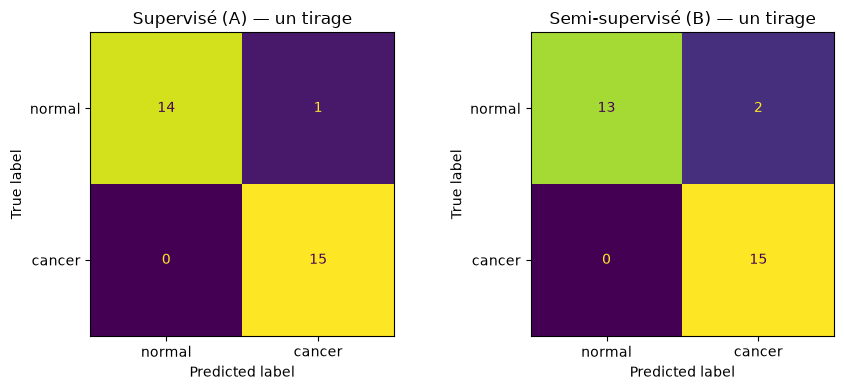

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

# Matrices de confusion d'UN découpage (seed 0) — illustration des erreurs, pas un résultat chiffré.
yA, yB = exemple["A"], exemple["B"]
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay.from_predictions(yA[0], yA[1], display_labels=["normal", "cancer"], ax=ax[0], colorbar=False)
ax[0].set_title("Supervisé (A) — un tirage")
ConfusionMatrixDisplay.from_predictions(yB[0], yB[1], display_labels=["normal", "cancer"], ax=ax[1], colorbar=False)
ax[1].set_title("Semi-supervisé (B) — un tirage")
fig.tight_layout()

Sur **5 découpages**, le verdict est clair : le semi-supervisé **n'apporte pas de gain net** — il
échange un peu de précision contre un peu de recall, mais l'AUC (~0,97) et le F1 (~0,92) ne dépassent
pas le supervisé. Cohérent avec l'enquête : la tâche est si **facile à cause du confondant** que le
modèle supervisé capte déjà tout le signal exploitable ; il ne reste **aucune marge** pour les
pseudo-labels. Un recall élevé n'est donc pas une victoire ici, c'est le symptôme du biais.

## 4.8 — Exploration : self-training itératif *sans fuite*

Dernière piste : pseudo-labéliser le pool par paliers de confiance décroissante, en réentraînant à
chaque tour. Pour que l'évaluation reste honnête, on utilise une **CV externe 5 folds** où, à chaque
fold, le test est sanctuarisé : il ne sert ni à scaler, ni à la PCA, ni à pseudo-labéliser. Les
pseudo-labels sont **régénérés dans chaque fold** (c'est ce qui rend cette boucle leakage-safe,
contrairement à une CV naïve qui réutiliserait les pseudo-labels globaux).

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

feat_all = np.load("../outputs/features_resnet50.npy")
idx_lab = np.where(mask98)[0]; idx_pool = np.where(~mask98)[0]
y_all = np.full(len(cat), -1, int); y_all[idx_lab] = y_full

def modele_proba(seed=0):
    # Modèle léger à predict_proba natif (rapide). On évite SVC(probability=True), dont la
    # calibration interne est très coûteuse quand on la réentraîne en boucle sur ~1 200 images.
    return LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced", random_state=seed)

def self_training(X, train_idx, pool_idx, seuils, w=0.35, max_iter=10, seed=0):
    # Ajoute itérativement les images du pool prédites au-dessus du seuil, avec un poids réduit.
    pseudo, restant = {}, np.array(pool_idx)
    for it in range(max_iter):
        seuil = seuils[min(it, len(seuils)-1)]
        idx = np.array(list(train_idx) + list(pseudo))
        yy = np.array([y_all[i] if y_all[i] != -1 else pseudo[i][0] for i in idx])
        poids = np.array([1.0 if y_all[i] != -1 else w*pseudo[i][1] for i in idx])
        m = modele_proba(seed+it).fit(X[idx], yy, sample_weight=poids)
        if len(restant) == 0: break
        p = m.predict_proba(X[restant]); conf = p.max(1); pred = m.classes_[p.argmax(1)]
        pris = conf >= seuil
        if not pris.any(): break
        for i, l, c in zip(restant[pris], pred[pris], conf[pris]): pseudo[int(i)] = (int(l), float(c))
        restant = restant[~pris]
    idx = np.array(list(train_idx) + list(pseudo))
    yy = np.array([y_all[i] if y_all[i] != -1 else pseudo[i][0] for i in idx])
    poids = np.array([1.0 if y_all[i] != -1 else w*pseudo[i][1] for i in idx])
    return modele_proba(seed+99).fit(X[idx], yy, sample_weight=poids), pseudo

strategies = {"Supervisé (référence)": None, "Self-training strict 0.95": [0.95],
              "Self-training progressif": [0.95, 0.95, 0.90, 0.90, 0.85, 0.85]}

lignes = []
for fold, (tr, te) in enumerate(StratifiedKFold(5, shuffle=True, random_state=42).split(idx_lab, y_full)):
    train_idx, test_idx = idx_lab[tr], idx_lab[te]
    # scaler + PCA ajustés SANS le fold de test (anti-fuite)
    fit_idx = np.r_[train_idx, idx_pool]
    sc = StandardScaler().fit(feat_all[fit_idx]); pc = PCA(50, random_state=0).fit(sc.transform(feat_all[fit_idx]))
    Xf = pc.transform(sc.transform(feat_all))
    for nom, seuils in strategies.items():
        if seuils is None:
            m, cov = modele_proba(fold).fit(Xf[train_idx], y_all[train_idx]), 0.0
        else:
            m, pseudo = self_training(Xf, train_idx, idx_pool, seuils, seed=fold)
            cov = len(pseudo) / len(idx_pool)                 # part du pool pseudo-labélisée
        proba = m.predict_proba(Xf[test_idx])[:, list(m.classes_).index(1)]
        lignes.append({"stratégie": nom, "recall_cancer": recall_score(y_all[test_idx], proba>=0.5, zero_division=0),
                       "F1": f1_score(y_all[test_idx], proba>=0.5, zero_division=0),
                       "ROC-AUC": roc_auc_score(y_all[test_idx], proba),
                       "couverture_pool": cov})

self_training_resume = pd.DataFrame(lignes).groupby("stratégie").mean().round(3)
self_training_resume.to_csv("../outputs/benchmark_self_training_iteratif_resume.csv")
self_training_resume

,recall_cancer,F1,ROC-AUC,couverture_pool
stratégie,,,,
Self-training progressif,0.88,0.881,0.967,0.966
Self-training strict 0.95,0.88,0.881,0.964,0.914
Supervisé (référence),0.90,0.891,0.953,0.000


Le self-training pseudo-labélise une **large part du pool** (colonne `couverture_pool`, ~90-97 %) tout
en gardant une performance **équivalente au supervisé** (AUC ~0,95-0,97). Sa valeur n'est donc pas
prédictive mais **opérationnelle** : réduire le volume à annoter. Il ne faut pas pour autant forcer les
cas peu confiants — ceux-là restent candidats à l'annotation experte.

## 4.9 — Conclusion : un verdict réaliste

**L'enquête a tranché.** Les scores élevés (AUC ≈ 0,98 même en validation croisée propre) ne sont pas
un succès mais un **signal de biais** : le jeu de données est confondu par le **protocole d'acquisition**
— au point qu'une bande d'image *sans cerveau* prédit déjà le cancer (AUC ≈ 0,8). Et **trois tentatives
de neutralisation échouent** : ni le prétraitement (recadrage / CLAHE), ni l'augmentation agressive
(luminosité, contraste, recadrage, bruit), ni même le **masquage pour ne garder que le cerveau** ne
retirent le biais (AUC plancher ~0,90-0,95). Preuve qu'il est **intrinsèque aux données** — dans
l'apparence du tissu cérébral lui-même — et non un défaut corrigeable côté modèle.

**Dispositions prises pour des résultats cohérents :**
- test **sanctuarisé** et partagé entre notebooks (plus de fuite inter-notebooks) ;
- préprocessing (scaler/PCA) **ajusté sans le test** ;
- évaluation en **CV / découpages répétés (moyenne ± écart-type)**, jamais un score isolé sur 30 images
  (un AUC ponctuel à 1,0 est un artefact, pas un résultat) ;
- **baseline-raccourci comme étalon** : on ne juge que le **gain au-dessus du raccourci** ;
- **augmentation photométrique** conservée comme bonne pratique (elle réduit la part la plus grossière du biais).

**Apport du semi-supervisé :** sur ce jeu, **nul côté prédiction** — le recall est déjà saturé par le
confondant, donc les pseudo-labels n'ajoutent aucun gain (ils échangent juste un peu de précision contre
un peu de recall). Sa seule valeur est **opérationnelle** : le self-training pseudo-labélise une large
part du pool à performance constante, ce qui **réduit le volume à annoter**. Et les scores absolus, des
deux côtés, restent **gonflés par le confondant** — à ne jamais lire sans la baseline-raccourci.

**Limites & recommandations métier :**
- très peu de labels → métriques instables, à lire avec leur écart-type ;
- biais d'acquisition **intrinsèque** → **le seul vrai remède est au niveau des données** : images
  *cancer* et *normal* issues des mêmes scanners/protocoles, ou harmonisation multi-sources ;
- stratégie défendable : transfer learning + augmentation photométrique + pseudo-labélisation prudente +
  self-training à seuil haut + **annotation experte ciblée** des cas ambigus + validation clinique.

> **Definition of done — NB2 :** pipeline sans fuite, confondant démontré, **trois tentatives de
> neutralisation testées** (prétraitement, augmentation, masquage cerveau), **aucun score sur un seul
> split**, apport du semi-supervisé mesuré *relativement à une baseline-raccourci*, verdict honnête.